신경망은 전 챕터에서 가중치를 수동으로 설정하는 것을 자동으로 학습하는 능력을 제공할 수 있게 된다.

### 퍼셉트론에서 신경망으로
신경망은 0층인 입력층, n-1층인 출력층, 1-(n-2)층인 은닉층이 있고 은닉층의 뉴런은 사람 눈에 보이지 않는다. 그럼 신경망에서 신호를 어떻게 전달할까? 일단 퍼셉트론은 이렇게 표현할 수 있다. y = h(b + w_1*x_1 + w_2*x_2), h(x) = 0 if x <= 0 else 1 이라 할 수 있다. h(x)는 일반적으로 활성화 함수라고 한다.

### 활성화 함수
활성화 함수는 임계값을 경계로 출력이 바뀐다. 이런 함수를 계단 함수라 한다. 그럼 계단 함수 이외의 함수를 사용하면 어떻게 될까?  
  
신경망에서 자주 이용하는 활성화 함수인 시그모이드 함수가 있다 1 / (1 +  exp(-x)) 꼴이다. 신경망에서는 이 함수를 이용해서 신호를 변환하고, 변환된 신호를 다음 뉴런에 전달한다. 사실 퍼셉트론과 신경망의 차이는 활성화 함수의 차이이다.  

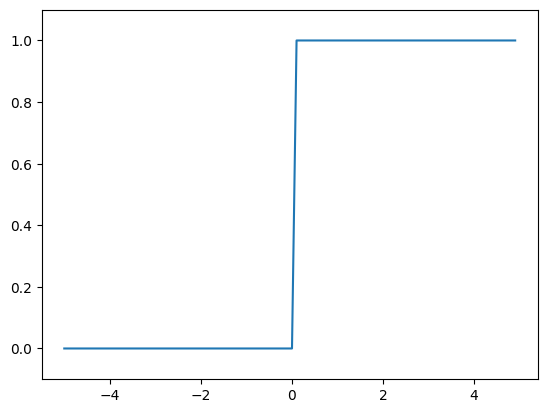

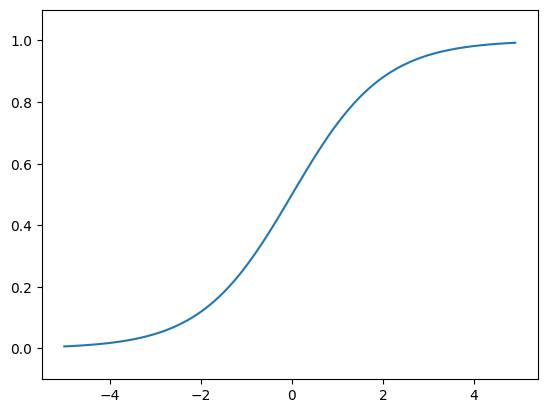

In [6]:
import numpy as np
import matplotlib.pylab as plt

def step_function(x):
    y = x > 0
    return y.astype(np.int32) # 이렇게 하면 넘파이 배열이 들어와도 결과를 반환 해준다.

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

x = np.arange(-5.0, 5.0, .1)
y = step_function(x)
plt.plot(x, y)
plt.ylim(-.1, 1.1)
plt.show()

y = sigmoid(x)
plt.plot(x, y)
plt.ylim(-.1, 1.1)
plt.show()

시그모이드 함수와 계단 함수의 차이는 매끄러움이 있는데 이는 신경망 학습에서 아주 중요하다. 연속적인 실수가 출력 결과로 나오기 때문이다. 둘의 공통점은 0과 1사이의 출력을 가진다. 그리고 비선형 함수이다.  
신경망에서는 활성화 함수로 비선형 함수를 써야 한다. 그런 이유는 선형 함수를 이용하면 신경망의 층을 깊게 하는 의미가 없어지기 때문이다. 층을 깊게 만든다고 한들 은닉층 없이도 똑같은 기능을 하는 네트워크를 만들 수 있기 때문이다. 17년 기준 주로 사용하는 함수는 ReLU 함수를 이용한다고 한다. h(x) = x if x > 0 else 0

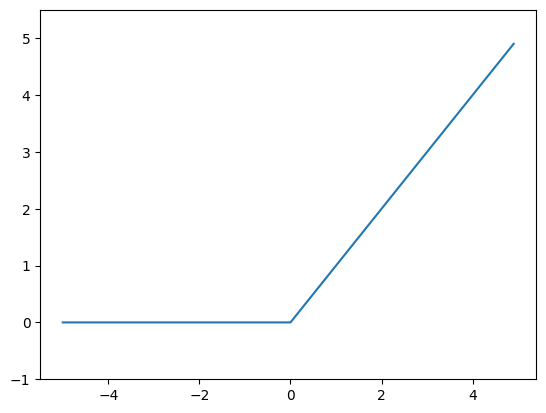

In [11]:
def relu(x):
    return np.maximum(0, x)

x = np.arange(-5.0, 5.0, .1)
y = relu(x)
plt.plot(x, y)
plt.ylim(-1, 5.5)
plt.show()


### 3층 신경망 구현하기

In [16]:
# 0층에서 1층
X = np.array([1., .5])
W1 = np.array([[.1, .3, .5], [.2, .4, .6]])
B1= np.array([.1, .2, .3])

print(W1.shape)
print(X.shape)
print(B1.shape)

A1 = np.dot(X, W1) + B1
Z1 = sigmoid(A1)

print(A1)
print(Z1) 

(2, 3)
(2,)
(3,)
[0.3 0.7 1.1]
[0.57444252 0.66818777 0.75026011]


In [17]:
# 1층에서 2층
W2 = np.array([[.1, .4], [.2, .5], [.3, .6]])
B2 = np.array([.1, .2])

print(Z1.shape)
print(W1.shape)
print(B2.shape)

A2 = np.dot(Z1, W2) + B2
Z2 = sigmoid(A2)

print(A2)
print(Z2)

(3,)
(2, 3)
(2,)
[0.51615984 1.21402696]
[0.62624937 0.7710107 ]


In [19]:
def identity_function(x):
    return x

W3 = np.array([[.1, .3], [.2, .4]])
B3 = np.array([.1, .2])

A3 = np.dot(Z2, W3) + B3
Y = identity_function(A3)

print(Y)

[0.31682708 0.69627909]


### 출력층 설계하기
신경망은 분류와 회귀 모두에 이용하는데 다만 둘 중 어떤 문제냐에 따라 출력층에서 사용되는 함수가 다르다. 일반적으로 회귀에는 항등함수를 분류에는 softmax함수를 사용한다.
여기서 항등함수는 입력을 그대로 출력한다. 소프트맥스함수는 식이 이렇다 y_k = exp(a_k) / sigma(n, i=1){exp(a_i)} ?  뭔가 확률 꼴이다.

In [21]:
def softmax(a):
    exp_a = np.exp(a)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

print(softmax(np.array([.3, 2.9, 4.0])))

[0.01821127 0.24519181 0.73659691]


이 소프트맥스함수는 오버플로가 나기 쉽다 그래서 식을 변형하였다. 

In [22]:
def softmax(a):
    c = np.max(a)
    exp_a = np.exp(a -c)
    sum_exp_a = np.sum(exp_a)
    y = exp_a / sum_exp_a

    return y

print(softmax(np.array([.3, 2.9, 4.0])))

[0.01821127 0.24519181 0.73659691]


소프트맥스 함수는 출력이 0과 1사이의 실수이고 출력의 총합은 1이다. 이 성질 덕분에 함수의 출력을 확률로 해석할 수 있다. 그리고 함수를 적용해도 각 원소의 대소 관계는 변하지 않는다.  
신경망을 이용한 분류에서는 일반적으로 가장 큰 출력을 내는 뉴런에 해당하는 클래스로만 인식한다.  

출력층의 뉴런 수는 문제에 맞게 적절히 정해야 한다. 분류를 할 때는 분류를 하고 싶은 클래스 수로 설정하는 편이다.

### 손글씨 숫자 인식
학습 과정은 생략하고 추론 과정을 구현해보자. 추론 과정은 신경망의 순전파라고도 한다.

In [27]:
import sys, os
sys.path.append(os.pardir)
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = \
    load_mnist(flatten =True, normalize=False)

print(x_train.shape)
print(t_train.shape)
print(x_test.shape)
print(t_test.shape)

Converting train-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting train-labels-idx1-ubyte.gz to NumPy Array ...
Done
Converting t10k-images-idx3-ubyte.gz to NumPy Array ...
Done
Converting t10k-labels-idx1-ubyte.gz to NumPy Array ...
Done
Creating pickle file ...
Done!
(60000, 784)
(60000,)
(10000, 784)
(10000,)


In [38]:
from PIL import Image

def img_show(img):
    pil_img = Image.fromarray(np.uint8(img))
    pil_img.show()

(x_train, t_train), (x_test, t_test) = \
    load_mnist(flatten =True, normalize=False)

img = x_train[0]
label = t_train[0]
print(label)

print(img.shape)
img = img.reshape(28, 28)
print(img.shape)

img_show(img)

5
(784,)
(28, 28)


이제 신경망의 추론처리를 구현할 것인데 입력층 뉴런을 784 = 28 * 28 개로 하고 출력층 뉴런을 10(0-9)개로 구성한다. 그리고 은닉층은 2개의 층으로 하고 50개 100개씩 한다. 둘의 수는 임의로 정한 값이다.

In [43]:
import pickle

def get_data():
    (x_train, t_train), (x_test, t_test) = \
        load_mnist(flatten =True, normalize=False, one_hot_label=False)
    return x_test, t_test

def init_network():
    with open("sample_weight.pkl", 'rb') as f:
        network = pickle.load(f)

    return network

def predict(network, x):
    W1, W2, W3 = network['W1'], network['W2'], network['W3'] 
    b1, b2, b3 = network['b1'], network['b2'], network['b3'] 

    a1 = np.dot(x, W1) + b1
    z1 = sigmoid(a1)
    a2 = np.dot(z1, W2) + b2
    z2 = sigmoid(a2)
    a3 = np.dot(z2, W3) + b3
    y = softmax(a3)

    return y

In [44]:
x, t = get_data()
network= init_network()

accuracy_cnt = 0
for i in range(len(x)):
    y = predict(network, x[i])
    p = np.argmax(y)
    if p == t[i]:
        accuracy_cnt += 1

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

Accuracy:0.9207


C:\Users\vilab\AppData\Local\Temp\ipykernel_12488\1301824283.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)
C:\Users\vilab\AppData\Local\Temp\ipykernel_12488\287543121.py:9: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))


현재의 코드는 이미지 하나 하나 신경망에 입력하는데 그냥 통째로 넣어도 될까? 행렬 연산에 의하면 상관 없고 결과가 뚱뚱해질 뿐이다.

In [45]:
x, t = get_data()
network= init_network()

batch_size = 100
accuracy_cnt = 0

for i in range(0, len(x), batch_size):
    x_batch = x[i:i+batch_size]
    y_batch = predict(network, x_batch)
    p = np.argmax(y_batch, axis=1)
    accuracy_cnt += np.sum(p == t[i:i+batch_size])

print("Accuracy:" + str(float(accuracy_cnt) / len(x)))

Accuracy:0.9207


C:\Users\vilab\AppData\Local\Temp\ipykernel_12488\1301824283.py:10: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  network = pickle.load(f)
C:\Users\vilab\AppData\Local\Temp\ipykernel_12488\287543121.py:9: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-x))
